In [3]:
import sys

sys.path.append(r"D:\Users\Hannes\Documents\Python Code\nRTD\lib")

import wandb
from wandb_util import extract_run_savepoint
from nRTD.rtd_fitting_5 import RTDModule, RTDDataModule

import matplotlib.pyplot as plt
import ICIW_Plots

plt.style.use(["ICIWstyle"])
plt.rcParams.update(
    {
        "font.size": 7,
    }
)

In [ ]:
run_ids = [
    "9zdn8e4q",  #  30 ml/min, 1 bar, RT
    "9e45c3ra",  # 120 ml/min, 4 bar, RT
    "hdjk7ueu",  #  30 ml/min, 1 bar, heated
    "xoqfjwvh",  # 120 ml/min, 4 bar, heated
]

labels = [
    r"$p=1\;\mathrm{bar},\quad T=298\;\mathrm{K}$",
    r"$p=4\;\mathrm{bar},\quad T=298\;\mathrm{K}$",
]

In [5]:
names = []
paths = []
for run_id in run_ids:
    name, ckpt_path = extract_run_savepoint(f"ice_ulm/HSA_MGA_nRTD/{run_id}")
    names.append(name)
    paths.append(ckpt_path)

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


In [17]:
Es = []
ts = []
for name, path in zip(names, paths):
    print(name, path)
    model = RTDModule.load_from_checkpoint(path)
    Es.append(model.net.E[0])
    ts.append(model.net.conv_layers[0].t_kernel.detach().numpy())

noble-capybara-175 d:\Users\Hannes\Documents\Python Code\nRTD\Experiments\HSA_004\visualization\artifacts\model-9zdn8e4q-v0\model.ckpt
volcanic-armadillo-174 d:\Users\Hannes\Documents\Python Code\nRTD\Experiments\HSA_004\visualization\artifacts\model-9e45c3ra-v0\model.ckpt


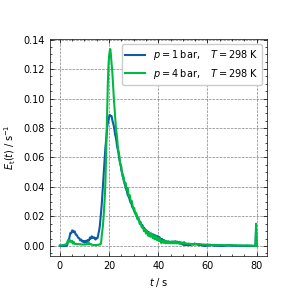

In [18]:
fig = ICIW_Plots.figure()
ax = ICIW_Plots.make_square_ax(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    left_h=0.5,
    xlabel=r"$t \;/\; \mathrm{s}$",
    ylabel=r"$E_\mathrm{t}(t)\;/\;\mathrm{s}^{-1}$",
)

for label, E, t in zip(labels, Es, ts):
    ax.plot(t, E, label=label)

ax.legend()